In [33]:
from tensorflow import keras
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import numpy as np
import imageio
import cv2
import os
import gc
import time


In [34]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
IMG_SIZE       = 299
MAX_SEQ_LENGTH = 15
BATCH_SIZE     = 8
EPOCHS         = 30
NUM_FEATURES   = 2048
#original dataset- https://www.kaggle.com/datasets/xdxd003/ff-c23 divided into train-test with ttest size=0.2 real=original, fake=mantype
#Manipulationtype: Deepfakes, face2face,faceshift,faceswap, neuraltextures
data_folder  = "/kaggle/input/datasets/shaheenafroz/Manipulationtype/dataset"
train_folder = "/kaggle/input/datasets/shaheenafroz/Manipulationtype/dataset/train"
test_folder  = "/kaggle/input/datasets/shaheenafroz/Manipulationtype/dataset/test"

In [36]:
def count_videos(folder, exts=(".mp4", ".avi", ".mov", ".mkv")):
    return sum(1 for f in os.listdir(folder) if f.lower().endswith(exts))

print("Fake train videos:", count_videos(os.path.join(train_folder, "fake")))
print("Real train videos:", count_videos(os.path.join(train_folder, "real")))

Fake train videos: 800
Real train videos: 800


In [37]:
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)


In [38]:
def crop_face(frame, expand_ratio=0.2):
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_detector.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )
    if len(faces) == 0:
        return None

    x, y, w, h = max(faces, key=lambda b: b[2] * b[3])

    expand_w = int(w * expand_ratio)
    expand_h = int(h * expand_ratio)
    x1 = max(x - expand_w, 0)
    y1 = max(y - expand_h, 0)
    x2 = min(x + w + expand_w, frame.shape[1])
    y2 = min(y + h + expand_h, frame.shape[0])

    return frame[y1:y2, x1:x2]


In [39]:
def load_video(path, max_frames=0):
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        return None

    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        face = crop_face(frame)
        if face is None:
            continue

        face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
        face = face[:, :, ::-1]  # BGR → RGB
        frames.append(face)

        if max_frames > 0 and len(frames) >= max_frames:
            break

    cap.release()
    return np.array(frames) if frames else None


In [40]:
def build_feature_extractor():
    base_model = keras.applications.Xception(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    
    base_model.trainable = False
    
    preprocess_input = keras.applications.xception.preprocess_input
    
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = preprocess_input(inputs)
    outputs = base_model(x)
    
    return keras.Model(inputs, outputs, name="feature_extractor")
feature_extractor = build_feature_extractor()

In [ ]:
def create_sampled_dataframe(folder, num_pairs=800):
    real_folder = os.path.join(folder, "real")
    fake_folder = os.path.join(folder, "fake")

    real_files = [
        f for f in os.listdir(real_folder)
        if f.lower().endswith((".mp4", ".avi", ".mov", ".mkv"))
    ]
    fake_files  = os.listdir(fake_folder)
    np.random.shuffle(real_files)

    video_data = []
    pair_count = 0

    for real_file in real_files:
        real_num       = real_file.split(".")[0]  # "669"
        
        matching_fakes = [f for f in fake_files if f.startswith(f"{real_num}_")]

        if matching_fakes:
            video_data.append({"path": os.path.join("real", real_file), "label": "REAL"})
            video_data.append({"path": os.path.join("fake", matching_fakes[0]), "label": "FAKE"})
            pair_count += 1

        if pair_count >= num_pairs:
            break

    df = pd.DataFrame(video_data).set_index("path")
    print(f"Created {pair_count} pairs ({2 * pair_count} videos)")
    return df

In [42]:
train_df = create_sampled_dataframe(train_folder, num_pairs=800)
test_df  = create_sampled_dataframe(test_folder,  num_pairs=200)

print("\nTrain label counts:\n", train_df["label"].value_counts())
print("\nTest label counts:\n",  test_df["label"].value_counts())

Created 800 pairs (1600 videos)
Created 200 pairs (400 videos)

Train label counts:
 label
REAL    800
FAKE    800
Name: count, dtype: int64

Test label counts:
 label
REAL    200
FAKE    200
Name: count, dtype: int64


In [43]:
def prepare_all_videos(df, root_dir):
    start_time   = time.time()
    num_samples  = len(df)
    video_paths  = list(df.index)
    labels       = (df["label"] == "FAKE").astype(int).values

    frame_masks    = np.zeros((num_samples, MAX_SEQ_LENGTH), dtype=bool)
    frame_features = np.zeros(
        (num_samples, MAX_SEQ_LENGTH, NUM_FEATURES), dtype="float16"  # ✅ float16 for memory
    )

    print(f"Processing {num_samples} videos from {root_dir}...")

    for idx, path in enumerate(video_paths):
        if idx % 25 == 0:
            elapsed = time.time() - start_time
            print(f"  [{idx}/{num_samples}] {elapsed / 60:.1f}m elapsed")

        frames = load_video(os.path.join(root_dir, path), max_frames=MAX_SEQ_LENGTH)

        if frames is not None and len(frames) > 0:
            length   = min(MAX_SEQ_LENGTH, len(frames))
            features = feature_extractor(frames[:length], training=False)

            frame_features[idx, :length, :] = features.numpy().astype("float16")
            frame_masks[idx, :length]        = True

            del features, frames
            gc.collect()

    print(f"Done in {(time.time() - start_time) / 60:.1f} minutes")
    return (frame_features.astype("float32"), frame_masks), labels

In [44]:
import numpy as np

SAVE_DIR = "/kaggle/input/datasets/shaheenafroz/neuraltextfeat/neuraltextfeatures"

# Make sure paths are correct with trailing slash
train_features_path = f"{SAVE_DIR}/train_features.npy"
train_masks_path    = f"{SAVE_DIR}/train_masks.npy"
train_labels_path   = f"{SAVE_DIR}/train_labels.npy"

test_features_path  = f"{SAVE_DIR}/test_features.npy"
test_masks_path     = f"{SAVE_DIR}/test_masks.npy"
test_labels_path    = f"{SAVE_DIR}/test_labels.npy"

if (all([os.path.exists(p) for p in 
        [train_features_path, train_masks_path, train_labels_path,
         test_features_path, test_masks_path, test_labels_path]])):

    print("Saved features found — loading...")

    train_data = (
        np.load(train_features_path),
        np.load(train_masks_path)
    )
    train_labels = np.load(train_labels_path)

    test_data = (
        np.load(test_features_path),
        np.load(test_masks_path)
    )
    test_labels = np.load(test_labels_path)

    print("Features loaded successfully!")

else:
    print("Some feature files are missing. Cannot load.")

Saved features found — loading...
Features loaded successfully!


In [45]:
print(f"\nTrain features : {train_data[0].shape}")
print(f"Train masks    : {train_data[1].shape}")
print(f"Train labels   : {len(train_labels)}")
print(f"\nTest features  : {test_data[0].shape}")
print(f"Test masks     : {test_data[1].shape}")
print(f"Test labels    : {len(test_labels)}")


Train features : (1600, 15, 2048)
Train masks    : (1600, 15)
Train labels   : 1600

Test features  : (400, 15, 2048)
Test masks     : (400, 15)
Test labels    : 400


In [46]:
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [47]:
def build_model():
    frame_features_input = keras.Input((MAX_SEQ_LENGTH, NUM_FEATURES))
    mask_input           = keras.Input((MAX_SEQ_LENGTH,), dtype="bool")

    # Fix 1: explicit mask passed to GRU layer 1
    x = keras.layers.GRU(
            64,
            return_sequences=True,
            kernel_regularizer=keras.regularizers.l2(0.001)
        )(frame_features_input, mask=mask_input)

    # Fix 2: explicit mask passed to GRU layer 2
    x = keras.layers.GRU(
            32,
            kernel_regularizer=keras.regularizers.l2(0.001)
        )(x, mask=mask_input)

    x = keras.layers.Dropout(0.5)(x)

    # Fix 3: BatchNorm before Dense head
    #x = keras.layers.BatchNormalization()(x)

    x = keras.layers.Dense(
            32,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.001)
        )(x)

    x = keras.layers.Dropout(0.4)(x)

    output = keras.layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model([frame_features_input, mask_input], output)
    model.compile(
        loss="binary_crossentropy",
        optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4),
        metrics=["accuracy"]
    )
    return model

In [48]:
model = build_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 15, 2048)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 15, 64)    │    405,888 │ input_layer_6[0]… │
│                     │                   │            │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_3 (GRU)         │ (None, 32)        │      9,408 │ gru_2[0][0],      │
│                     │                   │            │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ gru_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,056 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 416,385 (1.59 MB)

 Trainable params: 416,385 (1.59 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Fix 1: carve out a proper validation split from training data
(train_feats, val_feats,
 train_masks, val_masks,
 train_lbls,  val_lbls) = train_test_split(
    train_data[0], train_data[1], train_labels,
    test_size=0.15,
    random_state=42,
    stratify=train_labels        # keeps fake/real ratio balanced
)

In [50]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        "best_model.weights.h5",
        save_weights_only=True,
        save_best_only=True,
        monitor="val_loss",
        mode="min"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [51]:
history = model.fit(
    [train_feats, train_masks],
    train_lbls,
    validation_data=([val_feats, val_masks], val_lbls),  # Fix 1: proper val split
    callbacks=callbacks,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4920 - loss: 1.1413 - val_accuracy: 0.4958 - val_loss: 1.0354 - learning_rate: 1.0000e-04
Epoch 2/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5155 - loss: 1.0207 - val_accuracy: 0.5500 - val_loss: 0.9647 - learning_rate: 1.0000e-04
Epoch 3/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4869 - loss: 0.9630 - val_accuracy: 0.5083 - val_loss: 0.9282 - learning_rate: 1.0000e-04
Epoch 4/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4678 - loss: 0.9249 - val_accuracy: 0.5083 - val_loss: 0.9005 - learning_rate: 1.0000e-04
Epoch 5/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5243 - loss: 0.8911 - val_accuracy: 0.5375 - val_loss: 0.8835 - learning_rate: 1.0000e-04
Epoch 6/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4899 - loss: 0.8815 - val_accuracy: 0.5250 - val_loss: 0.8698 - learning_rate: 1.0000e-04
Epoch 7/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy:

In [52]:
from sklearn.metrics import classification_report, confusion_matrix

print("\n=== Test Set Evaluation ===")
test_preds       = model.predict([test_data[0], test_data[1]])
test_pred_labels = (test_preds > 0.5).astype(int).flatten()
print(confusion_matrix(test_labels, test_pred_labels))
print(classification_report(test_labels, test_pred_labels))

print("\n=== Train Set Evaluation ===")
train_preds       = model.predict([train_data[0], train_data[1]])
train_pred_labels = (train_preds > 0.5).astype(int).flatten()
print(confusion_matrix(train_labels, train_pred_labels))
print(classification_report(train_labels, train_pred_labels))


=== Test Set Evaluation ===
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
[[110  90]
 [ 72 128]]
              precision    recall  f1-score   support

           0       0.60      0.55      0.58       200
           1       0.59      0.64      0.61       200

    accuracy                           0.59       400
   macro avg       0.60      0.59      0.59       400
weighted avg       0.60      0.59      0.59       400


=== Train Set Evaluation ===
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[[564 236]
 [331 469]]
              precision    recall  f1-score   support

           0       0.63      0.70      0.67       800
           1       0.67      0.59      0.62       800

    accuracy                           0.65      1600
   macro avg       0.65      0.65      0.64      1600
weighted avg       0.65      0.65      0.64      1600



In [54]:
def predict_video(video_path):
    frames = load_video(video_path, max_frames=MAX_SEQ_LENGTH)
    if frames is None or len(frames) == 0:
        print("Video failed to load")
        return

    length         = min(MAX_SEQ_LENGTH, len(frames))
    features       = feature_extractor(frames[:length], training=False).numpy()

    frame_features = np.zeros((1, MAX_SEQ_LENGTH, NUM_FEATURES), dtype="float32")
    frame_mask     = np.zeros((1, MAX_SEQ_LENGTH), dtype="bool")

    frame_features[0, :length, :] = features
    frame_mask[0, :length]        = True

    prediction = model.predict([frame_features, frame_mask])[0][0]
    label      = "Fake" if prediction > 0.4 else "Real"

    print(f"Fake Probability : {prediction:.4f}")
    print(f"Real Probability : {1 - prediction:.4f}")
    print(f"Predicted Label  : {label}")

sample_path = os.path.join(train_folder, train_df.index[0])
predict_video(sample_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Fake Probability : 0.4118
Real Probability : 0.5882
Predicted Label  : Fake


In [55]:
print(sample_path)

/kaggle/input/datasets/shaheenafroz/neuraltextures/dataset/train/real/721.mp4


In [56]:
path2="/kaggle/input/datasets/shaheenafroz/tomcruise/Very realistic Tom Cruise Deepfake _ AI Tom Cruise.mp4"
predict_video(path2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Fake Probability : 0.5199
Real Probability : 0.4801
Predicted Label  : Fake


In [ ]:
model.save("modelmanipulationtype.keras")

In [ ]:
!zip -r modelworking.zip /kaggle/working

updating: kaggle/working/ (stored 0%)
updating: kaggle/working/best_model.weights.h5 (deflated 6%)
updating: kaggle/working/modelneural.keras (deflated 6%)
updating: kaggle/working/loss_plot.png (deflated 14%)
updating: kaggle/working/.virtual_documents/ (stored 0%)
updating: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 71%)
updating: kaggle/working/accuracy_plot.png (deflated 11%)
  adding: kaggle/working/training_curves.png (deflated 11%)
  adding: kaggle/working/test_performance_table.png (deflated 16%)
  adding: kaggle/working/confusion_matrix.png (deflated 24%)
  adding: kaggle/working/train_test_performance_table.png (deflated 20%)


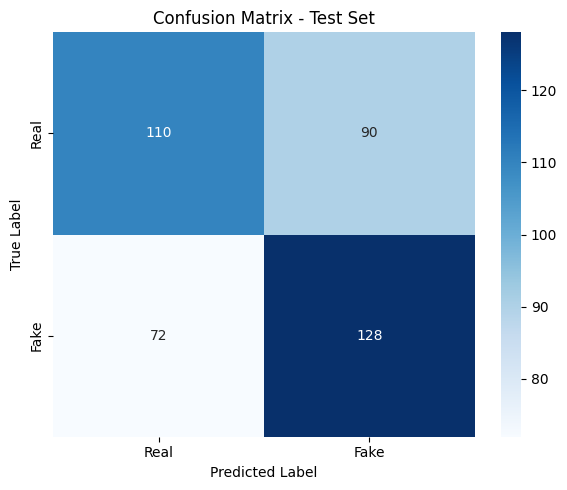

In [59]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, test_pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real","Fake"],
    yticklabels=["Real","Fake"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [60]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Generate report dictionary
test_report = classification_report(
    test_labels,
    test_pred_labels,
    target_names=["Real", "Fake"],
    output_dict=True
)

# Convert to dataframe
test_df = pd.DataFrame(test_report).transpose()

# Keep relevant rows
test_df = test_df.loc[["Real", "Fake", "macro avg", "weighted avg"]]

# Rename columns for paper
test_df = test_df.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1-score",
    "support": "Support"
})

test_df = test_df[["Precision", "Recall", "F1-score", "Support"]]

print(test_df)

              Precision  Recall  F1-score  Support
Real           0.604396   0.550  0.575916    200.0
Fake           0.587156   0.640  0.612440    200.0
macro avg      0.595776   0.595  0.594178    400.0
weighted avg   0.595776   0.595  0.594178    400.0


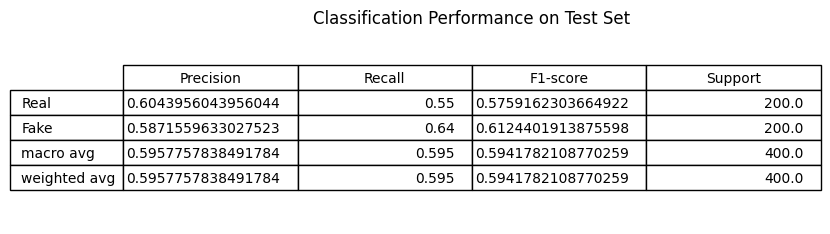

In [61]:
fig, ax = plt.subplots(figsize=(6,2.5))

ax.axis("tight")
ax.axis("off")

table = ax.table(
    cellText=test_df.values,
    colLabels=test_df.columns,
    rowLabels=test_df.index,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.5,1.5)

plt.title("Classification Performance on Test Set")

plt.savefig("test_performance_table.png", dpi=300, bbox_inches="tight")
plt.show()

In [62]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Generate report dictionary
train_report = classification_report(
    train_labels,
    train_pred_labels,
    target_names=["Real", "Fake"],
    output_dict=True
)

# Convert to dataframe
train_df = pd.DataFrame(train_report).transpose()

# Keep relevant rows
train_df = train_df.loc[["Real", "Fake", "macro avg", "weighted avg"]]

# Rename columns for paper
train_df = train_df.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1-score",
    "support": "Support"
})

train_df = train_df[["Precision", "Recall", "F1-score", "Support"]]

print(train_df)

              Precision    Recall  F1-score  Support
Real           0.630168  0.705000  0.665487    800.0
Fake           0.665248  0.586250  0.623256    800.0
macro avg      0.647708  0.645625  0.644371   1600.0
weighted avg   0.647708  0.645625  0.644371   1600.0


fig, ax = plt.subplots(figsize=(6,2.5))

ax.axis("tight")
ax.axis("off")

table = ax.table(
    cellText=train_df.values,
    colLabels=train_df.columns,
    rowLabels=train_df.index,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.5,1.5)

plt.title("Classification Performance on Train Set")

plt.savefig("train_performance_table.png", dpi=300, bbox_inches="tight")
plt.show()

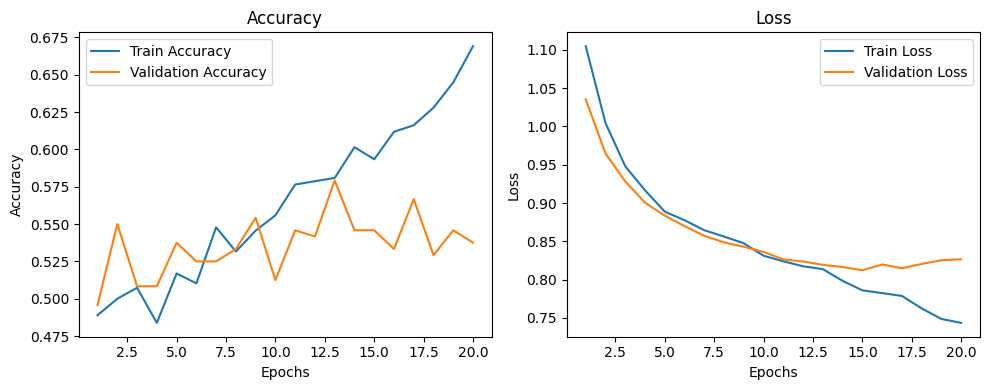

In [ ]:
import matplotlib.pyplot as plt

train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(10,4))

# Accuracy subplot
plt.subplot(1,2,1)
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss subplot
plt.subplot(1,2,2)
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

plt.savefig("training_curves.png", dpi=300)
plt.show()

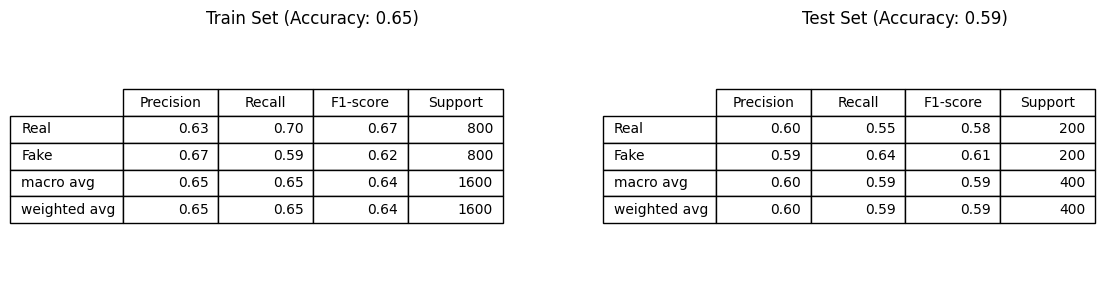

In [64]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# Function to format dataframe values to 2 decimals
def format_df(df):
    df_formatted = df.copy()
    for col in ["Precision", "Recall", "F1-score"]:
        df_formatted[col] = df_formatted[col].apply(lambda x: f"{x:.2f}")
    df_formatted["Support"] = df_formatted["Support"].astype(int)
    return df_formatted

# Generate train report
train_report = classification_report(
    train_labels,
    train_pred_labels,
    target_names=["Real", "Fake"],
    output_dict=True
)
train_df = pd.DataFrame(train_report).transpose()
train_df = train_df.loc[["Real", "Fake", "macro avg", "weighted avg"]]
train_df = train_df.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1-score",
    "support": "Support"
})
train_df = train_df[["Precision", "Recall", "F1-score", "Support"]]
train_df = format_df(train_df)
train_acc = accuracy_score(train_labels, train_pred_labels)

# Generate test report
test_report = classification_report(
    test_labels,
    test_pred_labels,
    target_names=["Real", "Fake"],
    output_dict=True
)
test_df = pd.DataFrame(test_report).transpose()
test_df = test_df.loc[["Real", "Fake", "macro avg", "weighted avg"]]
test_df = test_df.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1-score",
    "support": "Support"
})
test_df = test_df[["Precision", "Recall", "F1-score", "Support"]]
test_df = format_df(test_df)
test_acc = accuracy_score(test_labels, test_pred_labels)

# Plot both tables in one figure
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

for ax, df, title, acc in zip(axes, [train_df, test_df],
                              ["Train Set", "Test Set"], [train_acc, test_acc]):
    ax.axis("tight")
    ax.axis("off")
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        rowLabels=df.index,
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.5, 1.5)
    ax.set_title(f"{title} (Accuracy: {acc:.2f})")

plt.tight_layout()
plt.savefig("train_test_performance_table.png", dpi=300, bbox_inches="tight")
plt.show()